In [ ]:
import marimo as mo

# EE 446 TinyML — Model Pruning with Quantization
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.

## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.

In [ ]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

import gc

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()
gc.collect()

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

Python executable: /home/vkut/Documents/uni/tinyml/tinyml-arduino/bin/python3
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

BASE_DIR = Path("./assets")

data_dir = BASE_DIR / "data"
dataset_dir = data_dir / "UCI HAR Dataset"
zip_path = data_dir / "uci_har_dataset.zip"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

if not dataset_dir.exists():
    data_dir.mkdir(parents=True, exist_ok=True)
    urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")

Dataset already exists.


## 3. Load the Data

In [ ]:
def load_har_data():
    x_train = pd.read_csv(
        f"{dataset_dir}/train/X_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_train = pd.read_csv(
        f"{dataset_dir}/train/y_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    x_test = pd.read_csv(
        f"{dataset_dir}/test/X_test.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_test = pd.read_csv(
        f"{dataset_dir}/test/y_test.txt", sep='\s+', header=None
    ).values.astype("float32")

    y_train = y_train - 1
    y_test = y_test - 1
    y_train = y_train.flatten()
    y_test = y_test.flatten()

    print("Training data shape:", x_train.shape)
    print("Training labels shape:", y_train.shape)
    print("Test data shape:", x_test.shape)
    print("Test labels shape:", y_test.shape)

    return (x_train, y_train, x_test, y_test)

x_train, y_train, x_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = x_train.shape[1]   # 561
num_classes = len(class_names)    # 6

Training data shape: (7352, 561)
Training labels shape: (7352,)
Test data shape: (2947, 561)
Test labels shape: (2947,)


## 4. Quick Inspection

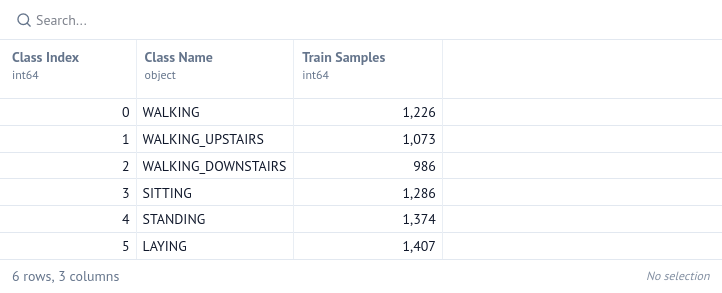

In [ ]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

train_counts = pd.Series(y_train).value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Train Samples": [int(train_counts.get(i, 0)) for i in range(num_classes)],
})
class_summary

## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)

In [ ]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4882 - accuracy: 0.8079 - val_loss: 0.2100 - val_accuracy: 0.9232
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1642 - accuracy: 0.9373 - val_loss: 0.1383 - val_accuracy: 0.9361
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1177 - accuracy: 0.9563 - val_loss: 0.2261 - val_accuracy: 0.9252
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0922 - accuracy: 0.9631 - val_loss: 0.1788 - val_accuracy: 0.9354
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0837 - accuracy: 0.9665 - val_loss: 0.2444 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0725 - accuracy: 0.9706 - val_loss: 0.1894 - val_accuracy: 0.9361
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0822 - accuracy: 0.9708 - val_loss: 0.1431 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

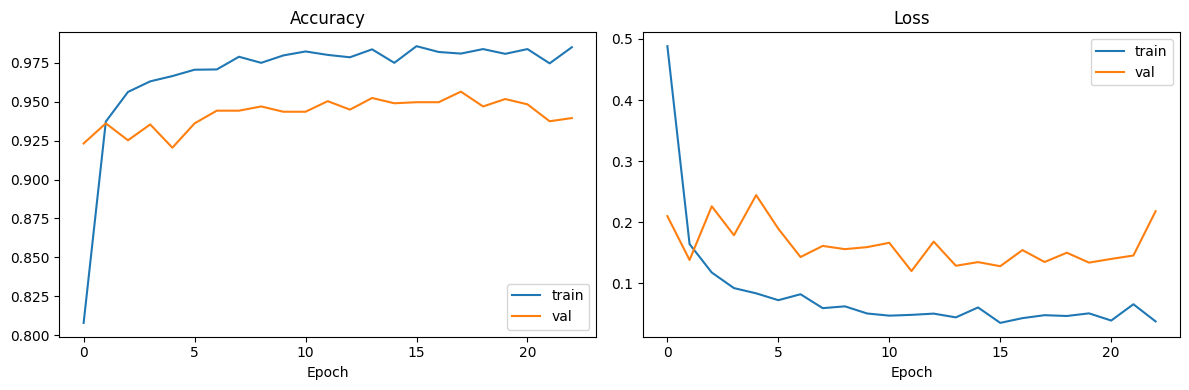

In [ ]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

fig_curves, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))

ax_acc.plot(history.history["accuracy"], label="train")
ax_acc.plot(history.history["val_accuracy"], label="val")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.legend()

ax_loss.plot(history.history["loss"], label="train")
ax_loss.plot(history.history["val_loss"], label="val")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 1ms/step
Baseline Keras test accuracy: 0.9342
                    precision    recall  f1-score   support

           WALKING       0.97      0.96      0.96       496
  WALKING_UPSTAIRS       0.91      0.97      0.94       471
WALKING_DOWNSTAIRS       0.95      0.90      0.93       420
           SITTING       0.96      0.83      0.89       491
          STANDING       0.84      0.97      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



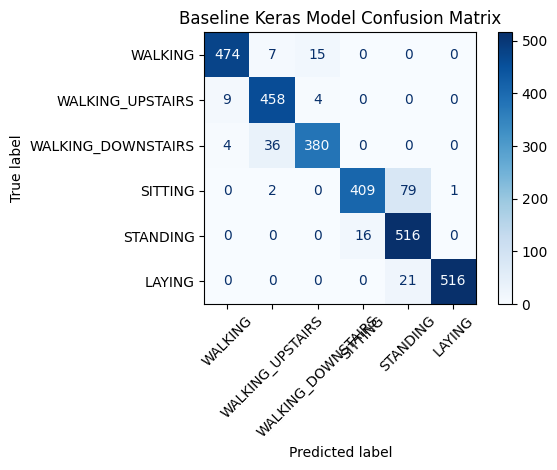

In [ ]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

baseline_probs = baseline_model.predict(x_test)
baseline_preds = np.argmax(baseline_probs, axis=1)

baseline_test_acc = accuracy_score(y_test, baseline_preds)
print("Baseline Keras test accuracy: {:.4f}".format(baseline_test_acc))
print(classification_report(y_test, baseline_preds, target_names=class_names))

baseline_cm = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(baseline_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues"
)
plt.title("Baseline Keras Model Confusion Matrix")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.

## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.

In [ ]:
def save_binary_model(model_content, filename):
    model_dir = Path(f"./{BASE_DIR}/pruning_quantization/models/")
    model_dir.mkdir(parents=True, exist_ok=True)

    filepath = model_dir / filename
    filepath.write_bytes(model_content)

    return filepath.stat().st_size / 1024  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    for i in range(300):
        sample = x_train[i:i + 1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            x = x.astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model

    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    return tflite_model

## 8. Convert the Baseline Model to TensorFlow Lite

In [ ]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32_kb = save_binary_model(tflite_fp32, "model_fp32.tflite")

acc_fp32, preds_fp32 = evaluate_tflite_model(tflite_fp32, x_test, y_test)

print(f"FP32:acc={acc_fp32:.4f} | size={size_fp32_kb:.1f} KB")

2026-07-15 13:00:14.839571: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 13:00:14.839598: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 13:00:14.839718: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpejnumdv3
2026-07-15 13:00:14.840455: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 13:00:14.840468: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpejnumdv3
2026-07-15 13:00:14.842499: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 13:00:14.865812: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpejnumdv3
2026-07-15 13:00:14.872031: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 32313 m

FP32:acc=0.9342 | size=726.7 KB


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.

In [ ]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = int(np.ceil(0.8 * x_train.shape[0] / batch_size))

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

def build_fresh_baseline():
    return keras.Sequential([
        keras.Input(shape=(num_features,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

pruned_model = prune_low_magnitude(build_fresh_baseline(), **pruning_params)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
pruned_model.summary()

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

pruned_history = pruned_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense   (None, 256)               287490    
 (PruneLowMagnitude)                                             
                                                                 
 prune_low_magnitude_dense_  (None, 128)               65666     
 1 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 64)                16450     
 2 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 6)                 776       
 3 (PruneLowMagnitude)                                           
                                                                 
Total params: 370382 (1.41 MB)
Trainable params: 185414 

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.

In [ ]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

tflite_pruned_with_mask = convert_to_tflite_fp32(pruned_model)
size_pruned_with_mask_kb = save_binary_model(tflite_pruned_with_mask, "model_pruned_with_mask.tflite")
acc_pruned_with_mask, preds_pruned_with_mask = evaluate_tflite_model(
    tflite_pruned_with_mask, x_test, y_test
)

stripped_model = strip_pruning(pruned_model)

def convert_to_tflite_sparse(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
    tflite_model = converter.convert()
    return tflite_model

tflite_stripped_sparse = convert_to_tflite_sparse(stripped_model)
size_stripped_sparse_kb = save_binary_model(tflite_stripped_sparse, "model_stripped_sparse.tflite")
acc_stripped_sparse, preds_stripped_sparse = evaluate_tflite_model(
    tflite_stripped_sparse, x_test, y_test
)

print(f"Pruned (with mask): acc={acc_pruned_with_mask:.4f} | size={size_pruned_with_mask_kb:.1f} KB")
print(f"Stripped Sparse: acc={acc_stripped_sparse:.4f} | size={size_stripped_sparse_kb:.1f} KB")

2026-07-15 13:00:23.060664: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 13:00:23.060689: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 13:00:23.060804: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3qrmz3yc
2026-07-15 13:00:23.062383: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 13:00:23.062395: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp3qrmz3yc
2026-07-15 13:00:23.067906: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 13:00:23.101036: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp3qrmz3yc
2026-07-15 13:00:23.111697: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 50893 m

Pruned (with mask): acc=0.9226 | size=1454.1 KB
Stripped Sparse: acc=0.9226 | size=338.8 KB


## 11. Part I Comparison: Accuracy and Model Size

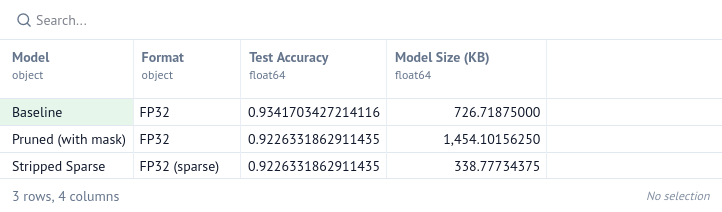

In [ ]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_results = pd.DataFrame({
    "Model": ["Baseline", "Pruned (with mask)", "Stripped Sparse"],
    "Format": ["FP32", "FP32", "FP32 (sparse)"],
    "Test Accuracy": [acc_fp32, acc_pruned_with_mask, acc_stripped_sparse],
    "Model Size (KB)": [size_fp32_kb, size_pruned_with_mask_kb, size_stripped_sparse_kb],
})
part1_results

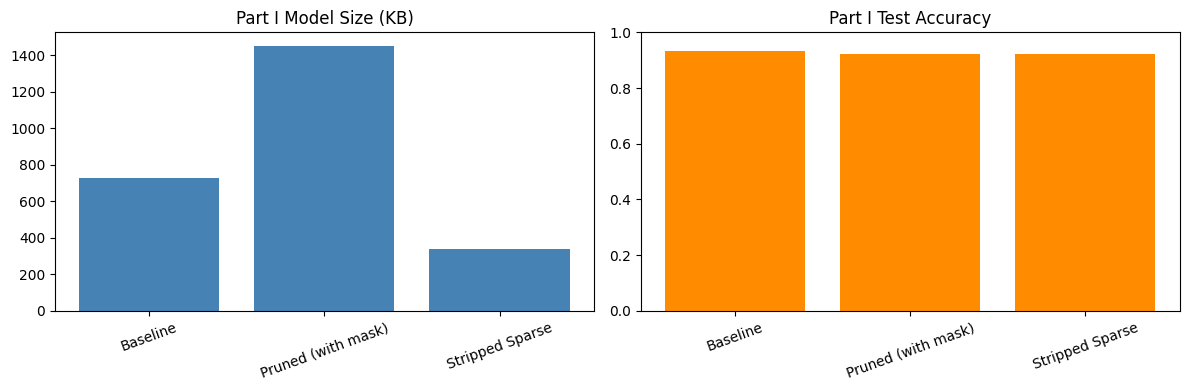

In [ ]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

fig_p1, (ax_size1, ax_acc1) = plt.subplots(1, 2, figsize=(12, 4))

ax_size1.bar(part1_results["Model"], part1_results["Model Size (KB)"], color="steelblue")
ax_size1.set_title("Part I Model Size (KB)")
ax_size1.tick_params(axis="x", rotation=20)

ax_acc1.bar(part1_results["Model"], part1_results["Test Accuracy"], color="darkorange")
ax_acc1.set_title("Part I Test Accuracy")
ax_acc1.set_ylim(0, 1.0)
ax_acc1.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.93      0.91       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.85      0.94      0.90       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



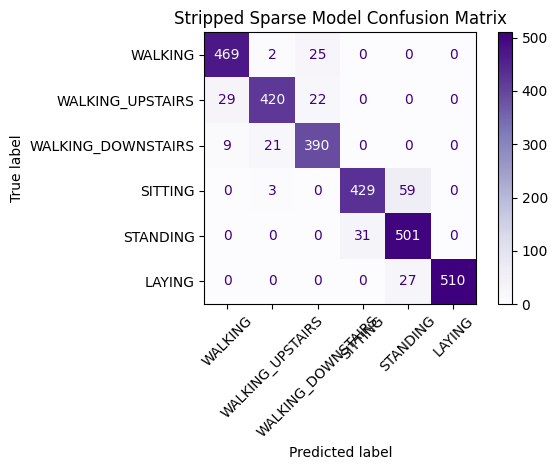

In [ ]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

print(classification_report(y_test, preds_stripped_sparse, target_names=class_names))

stripped_sparse_cm = confusion_matrix(y_test, preds_stripped_sparse)
ConfusionMatrixDisplay(stripped_sparse_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Purples"
)
plt.title("Stripped Sparse Model Confusion Matrix")
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.

In [ ]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

def convert_to_tflite_float16_pruned(model, sparsity_aware=False):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    optimizations = [tf.lite.Optimize.DEFAULT]
    if sparsity_aware:
        optimizations.append(tf.lite.Optimize.EXPERIMENTAL_SPARSITY)
    converter.optimizations = optimizations
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()
    return tflite_model

tflite_pruned_mask_fp16 = convert_to_tflite_float16_pruned(pruned_model, sparsity_aware=False)
size_pruned_mask_fp16_kb = save_binary_model(tflite_pruned_mask_fp16, "model_pruned_mask_fp16.tflite")
acc_pruned_mask_fp16, preds_pruned_mask_fp16 = evaluate_tflite_model(
    tflite_pruned_mask_fp16, x_test, y_test
)

tflite_stripped_sparse_fp16 = convert_to_tflite_float16_pruned(stripped_model, sparsity_aware=True)
size_stripped_sparse_fp16_kb = save_binary_model(tflite_stripped_sparse_fp16, "model_stripped_sparse_fp16.tflite")
acc_stripped_sparse_fp16, preds_stripped_sparse_fp16 = evaluate_tflite_model(
    tflite_stripped_sparse_fp16, x_test, y_test
)

print(f"Pruned + Float16 (with mask): acc={acc_pruned_mask_fp16:.4f} | size={size_pruned_mask_fp16_kb:.1f} KB")
print(f"Stripped Sparse + Float16: acc={acc_stripped_sparse_fp16:.4f} | size={size_stripped_sparse_fp16_kb:.1f} KB")

2026-07-15 13:00:26.922262: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 13:00:26.922289: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 13:00:26.922409: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpd2t0wxb9
2026-07-15 13:00:26.923949: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 13:00:26.923962: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpd2t0wxb9
2026-07-15 13:00:26.929580: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 13:00:26.963961: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpd2t0wxb9
2026-07-15 13:00:26.975395: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 52986 m

Pruned + Float16 (with mask): acc=0.9226 | size=732.5 KB
Stripped Sparse + Float16: acc=0.9226 | size=223.6 KB


## 12. Part II Comparison: Accuracy and Model Size

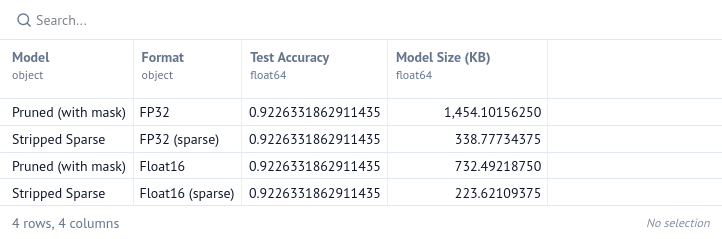

In [ ]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_results = pd.DataFrame({
    "Model": [
        "Pruned (with mask)",
        "Stripped Sparse",
        "Pruned (with mask)",
        "Stripped Sparse",
    ],
    "Format": ["FP32", "FP32 (sparse)", "Float16", "Float16 (sparse)"],
    "Test Accuracy": [
        acc_pruned_with_mask,
        acc_stripped_sparse,
        acc_pruned_mask_fp16,
        acc_stripped_sparse_fp16,
    ],
    "Model Size (KB)": [
        size_pruned_with_mask_kb,
        size_stripped_sparse_kb,
        size_pruned_mask_fp16_kb,
        size_stripped_sparse_fp16_kb,
    ],
})
part2_results

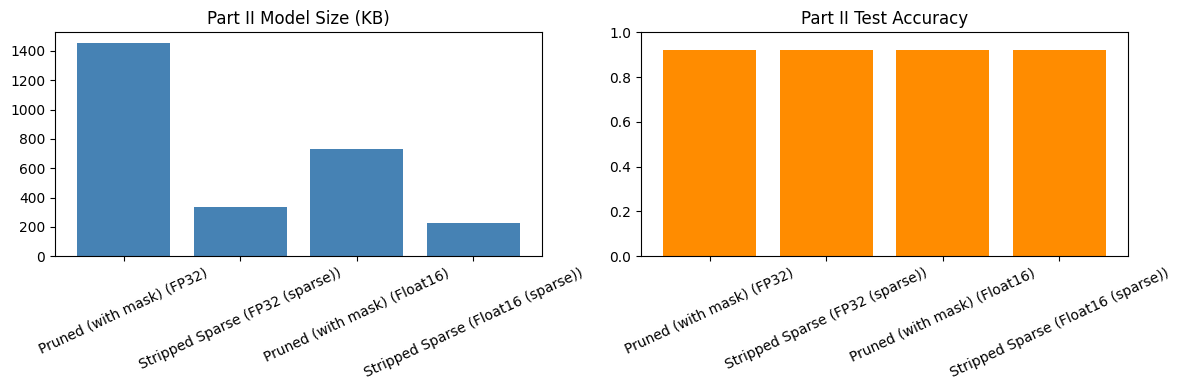

In [ ]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

fig_p2, (ax_size2, ax_acc2) = plt.subplots(1, 2, figsize=(12, 4))

labels_p2 = part2_results["Model"] + " (" + part2_results["Format"] + ")"

ax_size2.bar(labels_p2, part2_results["Model Size (KB)"], color="steelblue")
ax_size2.set_title("Part II Model Size (KB)")
ax_size2.tick_params(axis="x", rotation=25)

ax_acc2.bar(labels_p2, part2_results["Test Accuracy"], color="darkorange")
ax_acc2.set_title("Part II Test Accuracy")
ax_acc2.set_ylim(0, 1.0)
ax_acc2.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.93      0.91       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.85      0.94      0.90       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



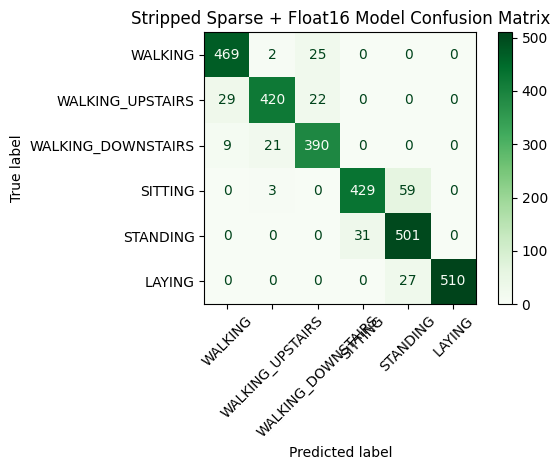

In [ ]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

print(classification_report(y_test, preds_stripped_sparse_fp16, target_names=class_names))

stripped_sparse_fp16_cm = confusion_matrix(y_test, preds_stripped_sparse_fp16)
ConfusionMatrixDisplay(stripped_sparse_fp16_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Greens"
)
plt.title("Stripped Sparse + Float16 Model Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
   > No, it actually doubled it.
3. Why does `strip_pruning(...)` matter before export?
   > it removes the mask and allows to ben
5. Which model had the smallest file size in this notebook?
   > Stripped sparse float16.
7. Did float16 quantization noticeably change the test accuracy?
   > No.
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   > Stripped sparse float32 since thats what devices usually have hw acceleration for.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.

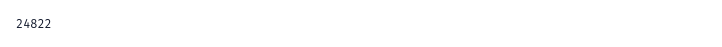

In [ ]:
# gimme my vram back

tf.keras.backend.clear_session()
gc.collect()